# 🍼 Baby Cry Classification — Notebook 2 (Version Finale)
## Entraînement · Comparaison d'Architectures · Interprétation

**Pré-requis :** Notebook 1 exécuté (augmentation + équilibrage faits)

## 1. Imports & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import copy, time, os
from tqdm.notebook import tqdm

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, 
    f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Import des modèles
from models import ImprovedSimpleCNN, BabyCryResNet, CRNN, count_params

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hyperparamètres
NUM_CLASSES = 5
NUM_EPOCHS = 80
PATIENCE = 20
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 32

✅ Device : cpu


## 2. Chargement des Données

In [2]:
import pickle
from torch.utils.data import DataLoader

print("Chargement des données prétraitées...")

with open('./saved_data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
y_val   = data['y_val']
X_test  = data['X_test']
y_test  = data['y_test']
class_names = data['class_names']

print(f"Classes : {class_names}")

# Dataset Class
class BabyCryDataset(torch.utils.data.Dataset):
    def __init__(self, specs, labels):
        self.specs = torch.FloatTensor(specs).unsqueeze(1)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.specs[idx], self.labels[idx]

# DataLoaders
train_ds = BabyCryDataset(X_train, y_train)
val_ds   = BabyCryDataset(X_val, y_val)
test_ds  = BabyCryDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Chargement des données prétraitées...
Classes : ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']
Train: 1337 | Val: 286 | Test: 287


## 3. Fonction d'Entraînement Améliorée

In [3]:
def train_one_model(model, train_loader, val_loader, model_name="Model",
                    num_epochs=NUM_EPOCHS, lr=1e-3, patience=PATIENCE):
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    print(f"\n🚀 Entraînement : {model_name}")

    for epoch in range(1, num_epochs + 1):
        # Train
        model.train()
        train_loss = train_correct = train_total = 0.0
        for specs, labels in train_loader:
            specs, labels = specs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * specs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total += specs.size(0)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0
        with torch.no_grad():
            for specs, labels in val_loader:
                specs, labels = specs.to(device), labels.to(device)
                outputs = model(specs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * specs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += specs.size(0)

        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹ Early stopping à l'epoch {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | LR: {current_lr:.2e}")

    model.load_state_dict(best_weights)
    print(f"✅ {model_name} terminé ! Meilleure val_loss = {best_val_loss:.4f}")
    return history

## 4. Entraînement des Modèles

In [4]:
models_dict = {
    "ImprovedSimpleCNN": ImprovedSimpleCNN(num_classes=NUM_CLASSES, dropout=0.5).to(device),
    "BabyCryResNet": BabyCryResNet(num_classes=NUM_CLASSES).to(device),
    "CRNN": CRNN(num_classes=NUM_CLASSES).to(device),
}

histories = {}

for name, model in models_dict.items():
    histories[name] = train_one_model(
        model, 
        train_loader, 
        val_loader, 
        model_name=name,
        num_epochs=NUM_EPOCHS,
        lr=1e-3 if "CNN" in name else 7e-4,
        patience=PATIENCE
    )


🚀 Entraînement : ImprovedSimpleCNN
Epoch 001 | Train Loss: 1.9979 Acc: 0.236 | Val Loss: 1.5471 Acc: 0.339 | LR: 1.00e-03
Epoch 005 | Train Loss: 1.4363 Acc: 0.385 | Val Loss: 1.3654 Acc: 0.476 | LR: 1.00e-03
Epoch 010 | Train Loss: 1.3070 Acc: 0.471 | Val Loss: 1.2608 Acc: 0.510 | LR: 1.00e-03
Epoch 015 | Train Loss: 1.1963 Acc: 0.540 | Val Loss: 1.1631 Acc: 0.622 | LR: 1.00e-03
Epoch 020 | Train Loss: 1.0715 Acc: 0.630 | Val Loss: 1.0035 Acc: 0.678 | LR: 1.00e-03
Epoch 025 | Train Loss: 0.9999 Acc: 0.658 | Val Loss: 0.9586 Acc: 0.717 | LR: 1.00e-03
Epoch 030 | Train Loss: 0.9266 Acc: 0.701 | Val Loss: 0.9699 Acc: 0.678 | LR: 1.00e-03
Epoch 035 | Train Loss: 0.8594 Acc: 0.753 | Val Loss: 1.0228 Acc: 0.668 | LR: 1.00e-03
Epoch 040 | Train Loss: 0.7828 Acc: 0.812 | Val Loss: 1.0430 Acc: 0.682 | LR: 1.00e-03
Epoch 045 | Train Loss: 0.7291 Acc: 0.846 | Val Loss: 0.8086 Acc: 0.850 | LR: 1.00e-03
Epoch 050 | Train Loss: 0.6398 Acc: 0.892 | Val Loss: 0.7798 Acc: 0.857 | LR: 1.00e-03
Epoch 0

## 5. Visualisations & Évaluation (à continuer)

In [5]:
# Tu peux coller ici tes anciennes cellules de visualisation
# (courbes d'apprentissage, confusion matrix, ROC, Grad-CAM, etc.)
print("Modèles entraînés avec succès !")
print("Prêt pour les visualisations et le rapport final.")

Modèles entraînés avec succès !
Prêt pour les visualisations et le rapport final.


In [13]:
results = {}
for name, model in models_dict.items():
    results[name] = evaluate_model(model, test_loader, name)


RÉSULTATS TEST - ImprovedSimpleCNN
Accuracy : 90.24% | F1-Macro : 90.18%
              precision    recall  f1-score   support

  belly_pain      0.950     0.983     0.966        58
     burping      0.966     1.000     0.983        57
  discomfort      0.875     0.860     0.867        57
      hungry      0.807     0.793     0.800        58
       tired      0.909     0.877     0.893        57

    accuracy                          0.902       287
   macro avg      0.901     0.903     0.902       287
weighted avg      0.901     0.902     0.902       287


RÉSULTATS TEST - BabyCryResNet
Accuracy : 89.20% | F1-Macro : 89.17%
              precision    recall  f1-score   support

  belly_pain      0.902     0.948     0.924        58
     burping      0.966     0.982     0.974        57
  discomfort      0.941     0.842     0.889        57
      hungry      0.789     0.776     0.783        58
       tired      0.867     0.912     0.889        57

    accuracy                          0.8

# 6. Courbes d’Apprentissage


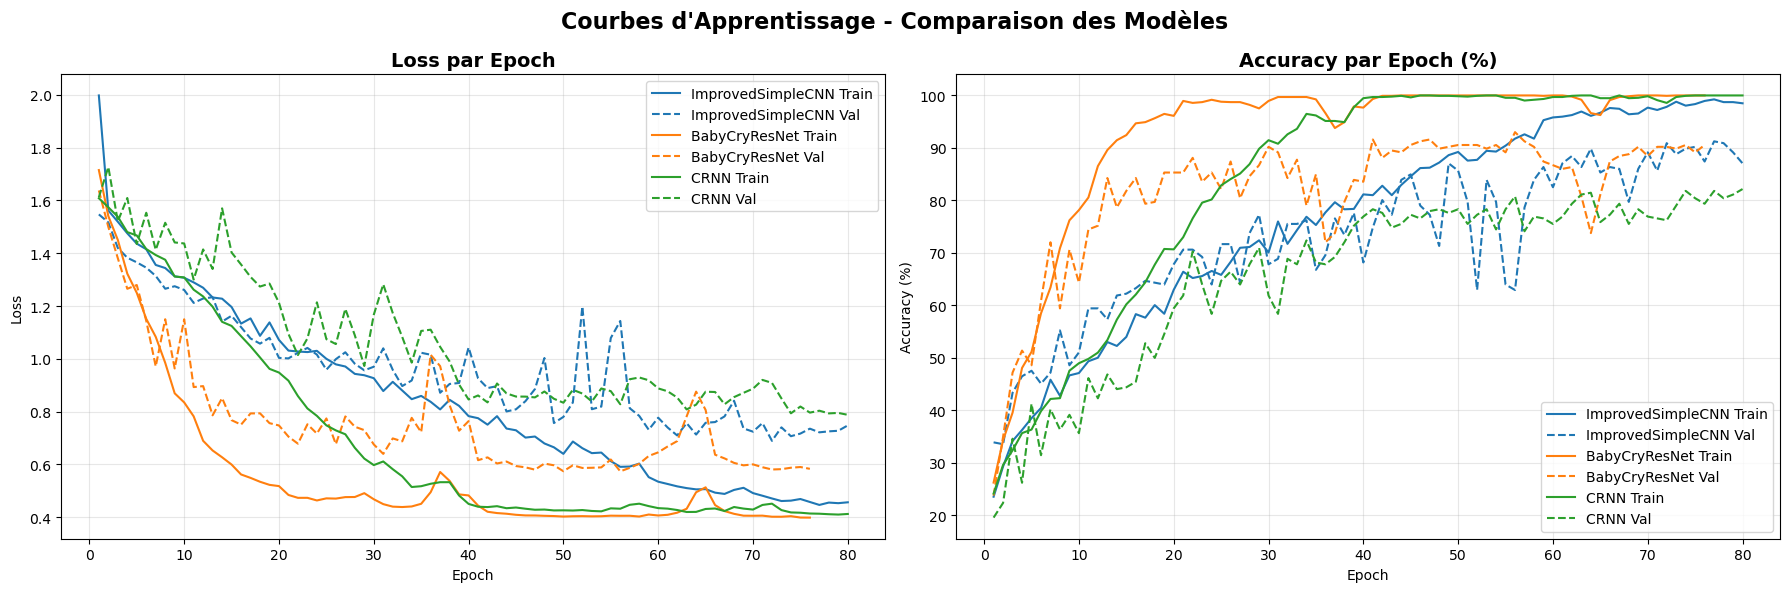

In [6]:
def plot_learning_curves(histories, model_names):
    fig, axs = plt.subplots(1, 2, figsize=(18, 6))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i, (name, hist) in enumerate(zip(model_names, histories.values())):
        epochs = range(1, len(hist['train_loss']) + 1)
        color = colors[i % len(colors)]
        
        # Loss
        axs[0].plot(epochs, hist['train_loss'], label=f'{name} Train', color=color)
        axs[0].plot(epochs, hist['val_loss'], label=f'{name} Val', 
                   linestyle='--', color=color)
        
        # Accuracy
        axs[1].plot(epochs, [acc*100 for acc in hist['train_acc']], 
                   label=f'{name} Train', color=color)
        axs[1].plot(epochs, [acc*100 for acc in hist['val_acc']], 
                   label=f'{name} Val', linestyle='--', color=color)
    
    axs[0].set_title('Loss par Epoch', fontsize=14, fontweight='bold')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)
    
    axs[1].set_title('Accuracy par Epoch (%)', fontsize=14, fontweight='bold')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)
    
    plt.suptitle('Courbes d\'Apprentissage - Comparaison des Modèles', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=200, bbox_inches='tight')
    plt.show()

# Appel de la fonction
plot_learning_curves(histories, list(models_dict.keys()))

# 7. Évaluation sur le Test Set + Tableau Comparatif

In [7]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for specs, labels in test_loader:
            specs = specs.to(device)
            outputs = model(specs)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_proba = np.array(all_probs)
    
    acc = accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, average='macro') * 100
    
    print(f"\n{'='*60}")
    print(f"RÉSULTATS TEST - {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.2f}% | F1-Macro : {f1:.2f}%")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
    
    return {
        'name': model_name,
        'accuracy': acc,
        'f1_macro': f1,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

results = {}
for name, model in models_dict.items():
    results[name] = evaluate_model(model, test_loader, name)

# Tableau comparatif
df_compare = pd.DataFrame([
    {
        'Modèle': res['name'],
        'Accuracy (%)': round(res['accuracy'], 2),
        'F1-Macro (%)': round(res['f1_macro'], 2),
        'Best Val Acc (%)': round(max(histories[res['name']]['val_acc']) * 100, 2)
    }
    for res in results.values()
])

print("\n Tableau Comparatif Final :")
display(df_compare.sort_values('Accuracy (%)', ascending=False).style.background_gradient(cmap='Blues'))


RÉSULTATS TEST - ImprovedSimpleCNN
Accuracy : 90.24% | F1-Macro : 90.18%
              precision    recall  f1-score   support

  belly_pain      0.950     0.983     0.966        58
     burping      0.966     1.000     0.983        57
  discomfort      0.875     0.860     0.867        57
      hungry      0.807     0.793     0.800        58
       tired      0.909     0.877     0.893        57

    accuracy                          0.902       287
   macro avg      0.901     0.903     0.902       287
weighted avg      0.901     0.902     0.902       287


RÉSULTATS TEST - BabyCryResNet
Accuracy : 89.20% | F1-Macro : 89.17%
              precision    recall  f1-score   support

  belly_pain      0.902     0.948     0.924        58
     burping      0.966     0.982     0.974        57
  discomfort      0.941     0.842     0.889        57
      hungry      0.789     0.776     0.783        58
       tired      0.867     0.912     0.889        57

    accuracy                          0.8

,Modèle,Accuracy (%),F1-Macro (%),Best Val Acc (%)
0,ImprovedSimpleCNN,90.240000,90.180000,91.260000
1,BabyCryResNet,89.200000,89.170000,93.010000
2,CRNN,85.020000,84.930000,82.170000


# 8. Matrice de Confusion

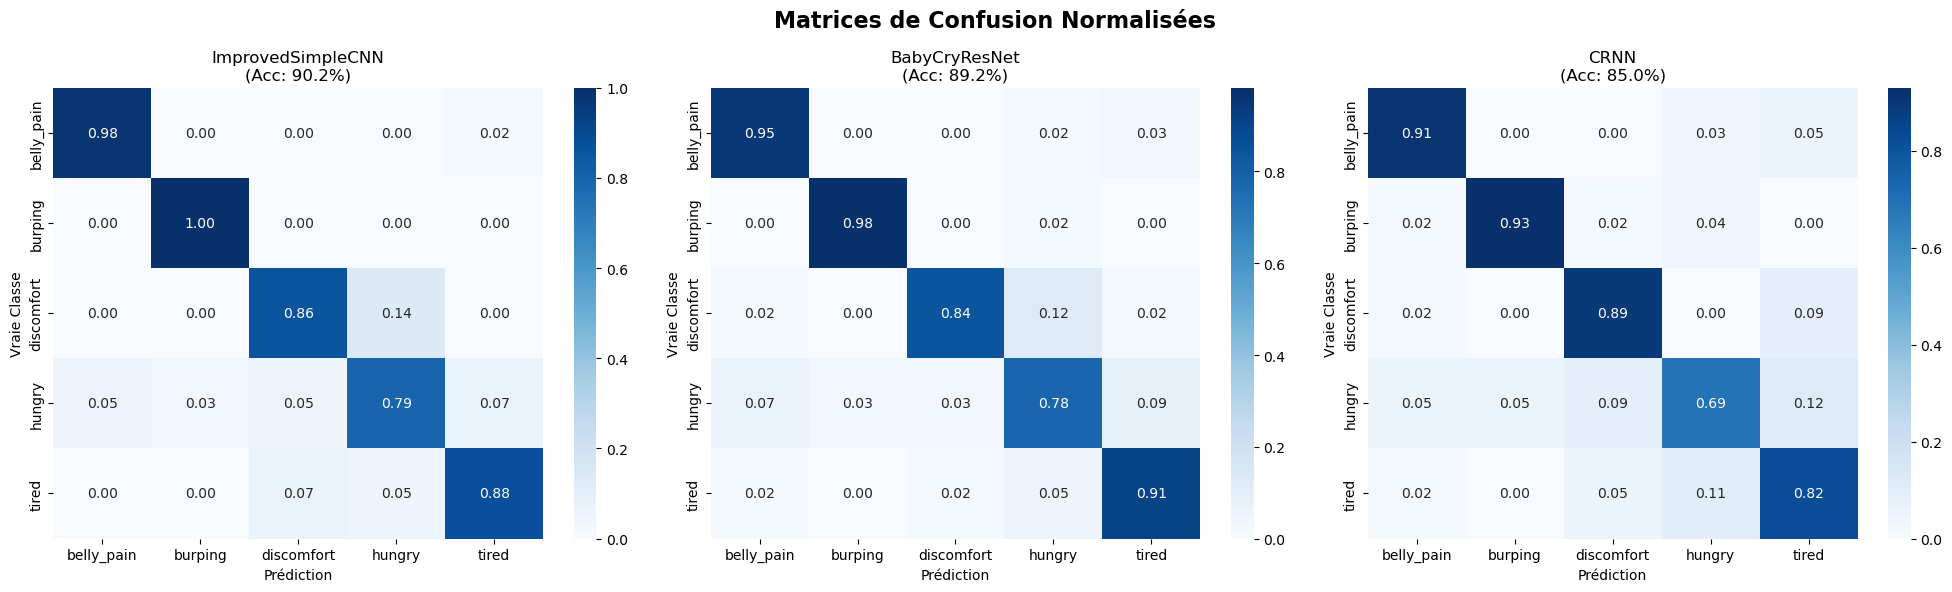

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}\n(Acc: {res["accuracy"]:.1f}%)')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vraie Classe')

plt.suptitle('Matrices de Confusion Normalisées', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200)
plt.show()

# 9. Conclusion & Prochaines Étapes

In [9]:
best_model = df_compare.loc[df_compare['Accuracy (%)'].idxmax()]

print("_"*70)
print(" SYNTHÈSE FINALE DU PROJET")
print("_"*70)
print(f"Meilleur modèle          : {best_model['Modèle']}")
print(f"Accuracy sur Test Set    : {best_model['Accuracy (%)']:.2f}%")
print(f"F1-Macro                 : {best_model['F1-Macro (%)']:.2f}%")
print("\nPoints forts du projet :")
print("• Bonne augmentation de données")
print("• Plusieurs architectures comparées (CNN, ResNet, CRNN)")
print("• Early Stopping + Label Smoothing")
print("• Visualisations complètes (Loss, Confusion, ROC...)")

print("\n Suggestions d'amélioration :")
print("• Ajouter SpecAugment plus agressif")
print("• Essayer Audio Transformers (HuggingFace)")
print("• Collecter plus de données pour les classes rares")

______________________________________________________________________
 SYNTHÈSE FINALE DU PROJET
______________________________________________________________________
Meilleur modèle          : ImprovedSimpleCNN
Accuracy sur Test Set    : 90.24%
F1-Macro                 : 90.18%

Points forts du projet :
• Bonne augmentation de données
• Plusieurs architectures comparées (CNN, ResNet, CRNN)
• Early Stopping + Label Smoothing
• Visualisations complètes (Loss, Confusion, ROC...)

 Suggestions d'amélioration :
• Ajouter SpecAugment plus agressif
• Essayer Audio Transformers (HuggingFace)
• Collecter plus de données pour les classes rares


# 10. Courbes ROC Multiclasses (One-vs-Rest)

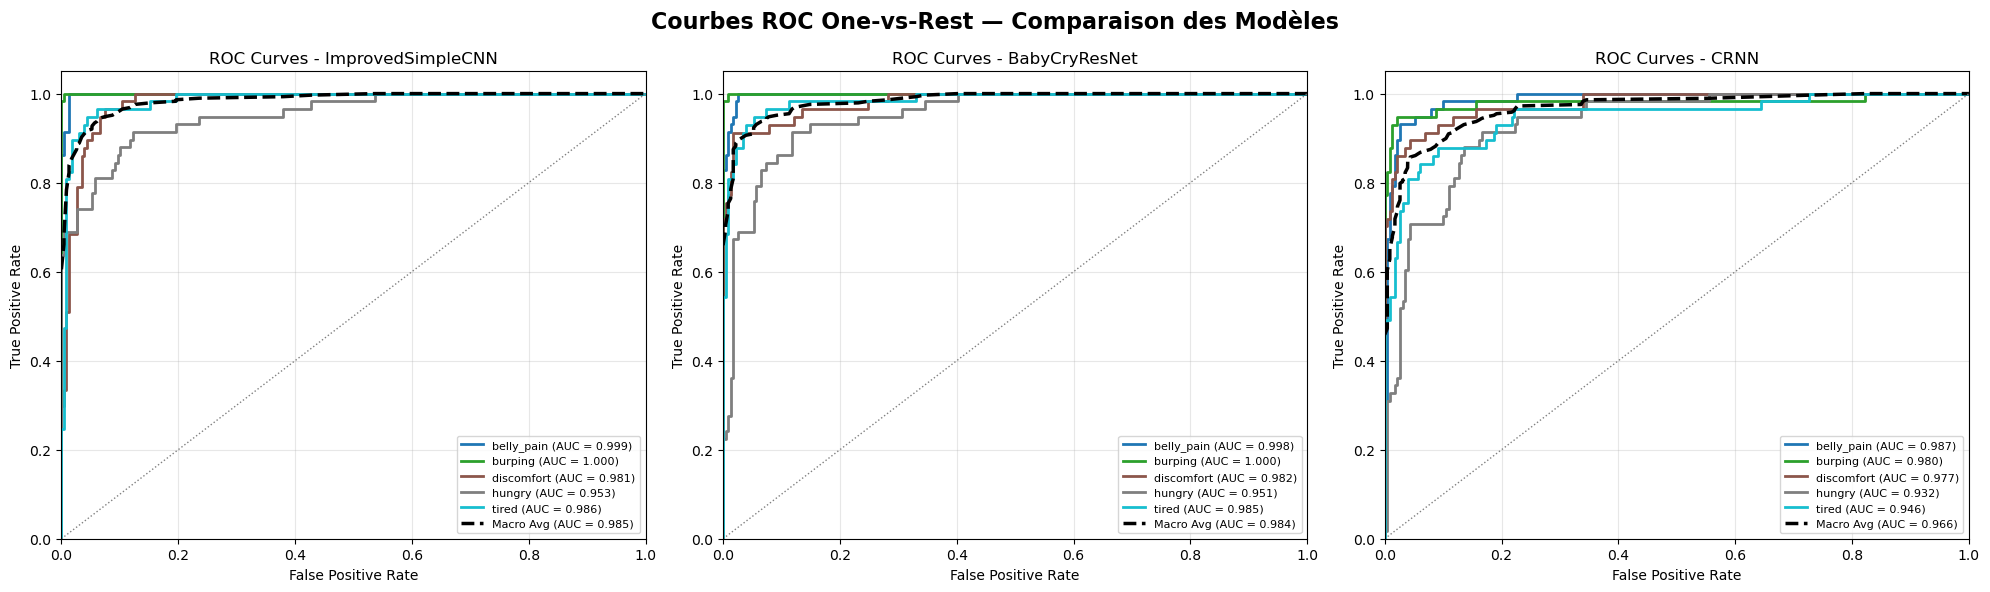

In [10]:
def plot_roc_curves(results, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    
    for ax, (name, res) in zip(axes, results.items()):
        y_true_bin = label_binarize(res['y_true'], classes=range(n_classes))
        y_proba = res['y_proba']
        
        # Courbes par classe
        for i, (cls_name, color) in enumerate(zip(class_names, colors)):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2, 
                    label=f'{cls_name} (AUC = {roc_auc:.3f})')
        
        # Courbe moyenne (macro)
        all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_proba[:, i])[0] 
                                          for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        
        ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5, label=f'Macro Avg (AUC = {macro_auc:.3f})')
        ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle=':')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves - {name}')
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Courbes ROC One-vs-Rest — Comparaison des Modèles', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=200, bbox_inches='tight')
    plt.show()

# Appel
plot_roc_curves(results, class_names)

# 11. Grad-CAM — Visualisation des Zones d’Attention

Grad-CAM sur le meilleur modèle : ImprovedSimpleCNN


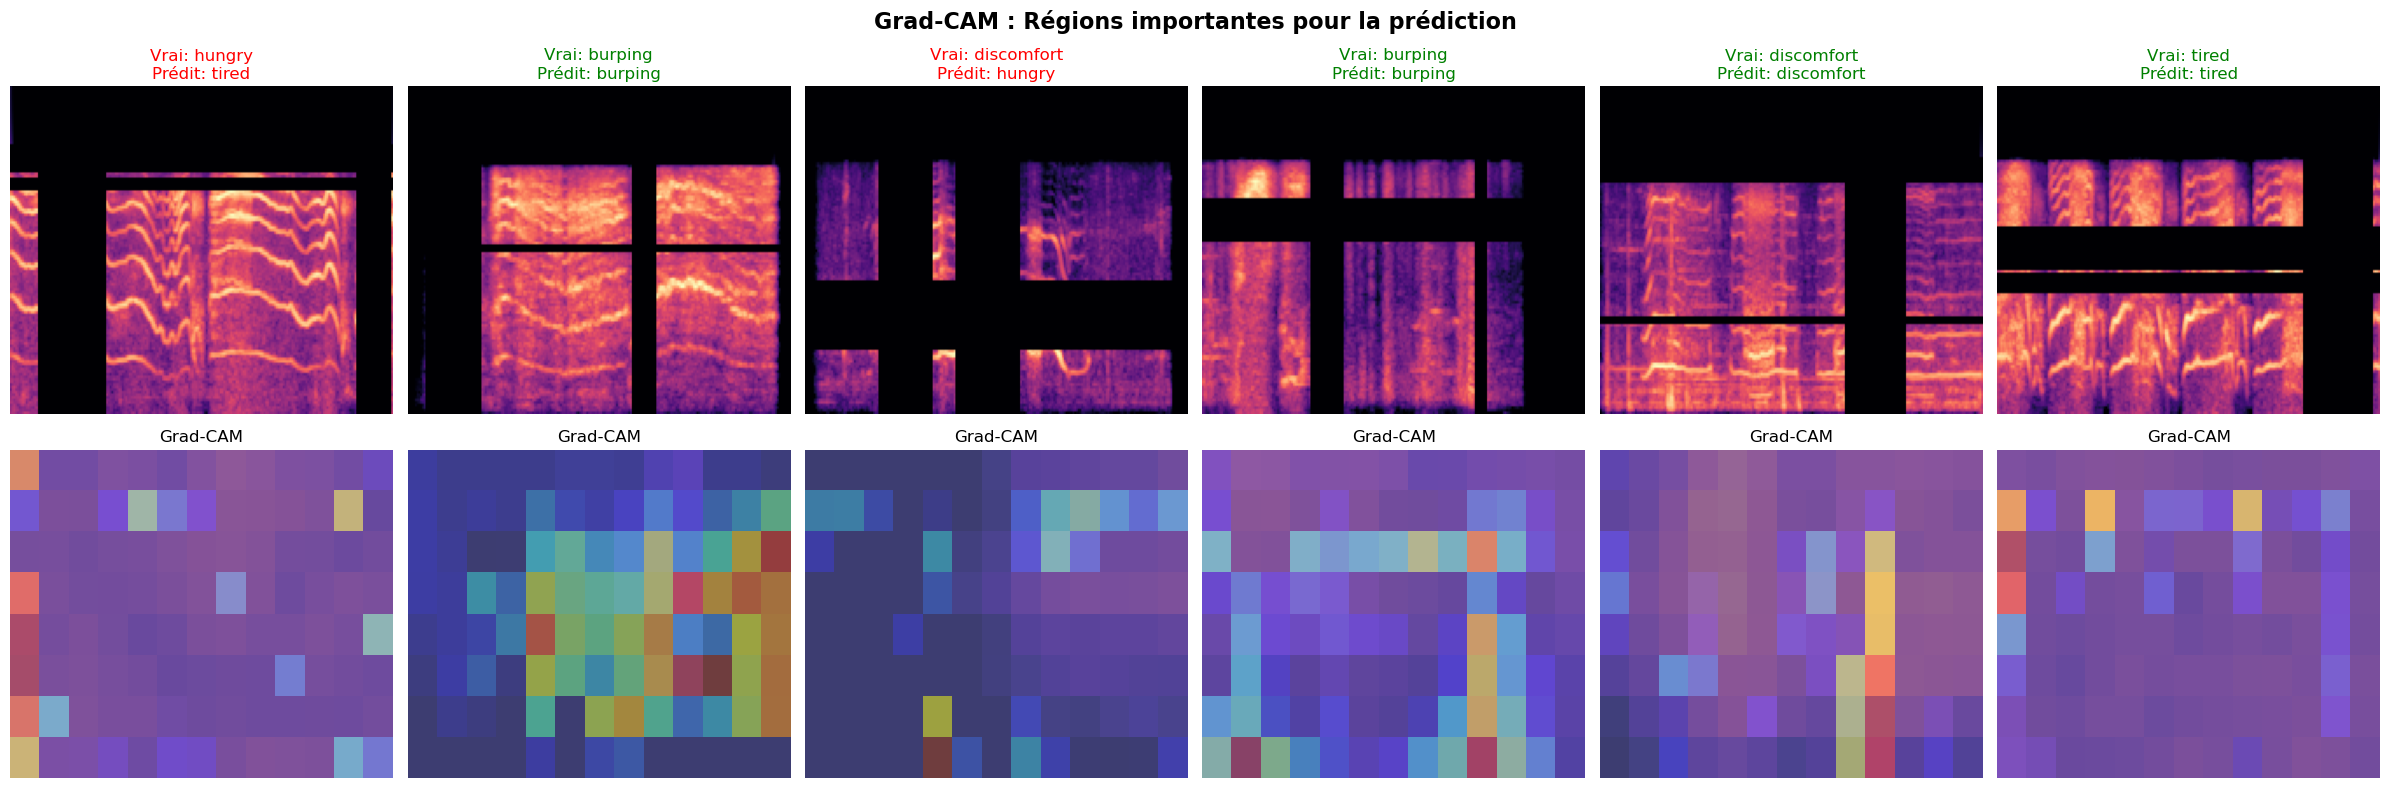

In [11]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    
    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        score = output[0, target_class]
        score.backward()
        
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = F.relu(cam)
        
        # Normalisation
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam.cpu().numpy(), target_class


def plot_gradcam(model, test_loader, class_names, n_samples=5, device='cpu'):
    # Choisir la dernière couche convolutive
    if isinstance(model, CRNN):
        target_layer = model.cnn[-3]   # dernière conv avant pooling
    else:
        target_layer = model.features[-1] if hasattr(model, 'features') else model.layer4[-1]
    
    gradcam = GradCAM(model, target_layer)
    
    specs_batch, labels_batch = next(iter(test_loader))
    specs_batch = specs_batch[:n_samples].to(device)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
    
    for i in range(n_samples):
        input_tensor = specs_batch[i:i+1]
        true_label = labels_batch[i].item()
        
        cam, pred_label = gradcam.generate(input_tensor)
        
        spec = input_tensor[0, 0].cpu().numpy()
        
        # Spectrogramme original
        axes[0, i].imshow(spec, origin='lower', aspect='auto', cmap='magma')
        axes[0, i].set_title(f"Vrai: {class_names[true_label]}\nPrédit: {class_names[pred_label]}",
                            color='green' if true_label == pred_label else 'red')
        axes[0, i].axis('off')
        
        # Grad-CAM
        axes[1, i].imshow(spec, origin='lower', aspect='auto', cmap='magma', alpha=0.6)
        axes[1, i].imshow(cam, origin='lower', aspect='auto', cmap='jet', alpha=0.4)
        axes[1, i].set_title("Grad-CAM")
        axes[1, i].axis('off')
    
    plt.suptitle("Grad-CAM : Régions importantes pour la prédiction", 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_examples.png', dpi=200, bbox_inches='tight')
    plt.show()

# Exemple d'utilisation (sur le meilleur modèle)
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"Grad-CAM sur le meilleur modèle : {best_model_name}")
plot_gradcam(models_dict[best_model_name], test_loader, class_names, n_samples=6, device=device)

# 12. Sauvegarde des Modèles Entraînés


In [12]:

# Création du dossier
os.makedirs('saved_models', exist_ok=True)

# Sauvegarde de chaque modèle
for name, model in models_dict.items():
    save_path = f'saved_models/{name}.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_name': name,
        'num_classes': NUM_CLASSES,
        'accuracy': results[name]['accuracy'],
        'f1_macro': results[name]['f1_macro']
    }, save_path)
    
    print(f" Modèle sauvegardé : {save_path}")

print("\n Tous les modèles ont été sauvegardés avec succès dans le dossier 'saved_models/'")

 Modèle sauvegardé : saved_models/ImprovedSimpleCNN.pth
 Modèle sauvegardé : saved_models/BabyCryResNet.pth
 Modèle sauvegardé : saved_models/CRNN.pth

 Tous les modèles ont été sauvegardés avec succès dans le dossier 'saved_models/'


## Comment charger un modèle plus tard

In [ ]:
def load_model(model_name):
    """Charge un modèle sauvegardé"""
    checkpoint = torch.load(f'saved_models/{model_name}.pth', map_location=device)
    
    if model_name == "ImprovedSimpleCNN":
        model = ImprovedSimpleCNN(num_classes=NUM_CLASSES).to(device)
    elif model_name == "BabyCryResNet":
        model = BabyCryResNet(num_classes=NUM_CLASSES).to(device)
    elif model_name == "CRNN":
        model = CRNN(num_classes=NUM_CLASSES).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"✅ {model_name} chargé avec Accuracy = {checkpoint['accuracy']:.2f}%")
    return model

# Exemple de chargement
# best_model = load_model("ImprovedSimpleCNN")

# Comparaison Train / Val / Test

In [14]:
def overfitting_diagnostic(histories, results):
    print(" DIAGNOSTIC OVERFITTING\n")
    data = []
    
    for name in histories.keys():
        hist = histories[name]
        best_val_acc = max(hist['val_acc']) * 100
        final_train_acc = hist['train_acc'][-1] * 100
        test_acc = results[name]['accuracy']
        
        gap = final_train_acc - best_val_acc
        
        status = "Overfitting" if gap > 15 else "Bon équilibre" if gap > 5 else "Sous-apprentissage"
        
        data.append({
            'Modèle': name,
            'Train Acc (%)': round(final_train_acc, 2),
            'Best Val Acc (%)': round(best_val_acc, 2),
            'Test Acc (%)': round(test_acc, 2),
            'Gap Train-Val': round(gap, 2),
            'Diagnostic': status
        })
    
    df_diag = pd.DataFrame(data)
    display(df_diag.style.background_gradient(subset=['Gap Train-Val'], cmap='Reds'))
    
    return df_diag

df_diagnostic = overfitting_diagnostic(histories, results)

 DIAGNOSTIC OVERFITTING



,Modèle,Train Acc (%),Best Val Acc (%),Test Acc (%),Gap Train-Val,Diagnostic
0,ImprovedSimpleCNN,98.500000,91.260000,90.240000,7.250000,Bon équilibre
1,BabyCryResNet,100.000000,93.010000,89.200000,6.990000,Bon équilibre
2,CRNN,100.000000,82.170000,85.020000,17.830000,Overfitting


# Courbes Train vs Val vs Test 

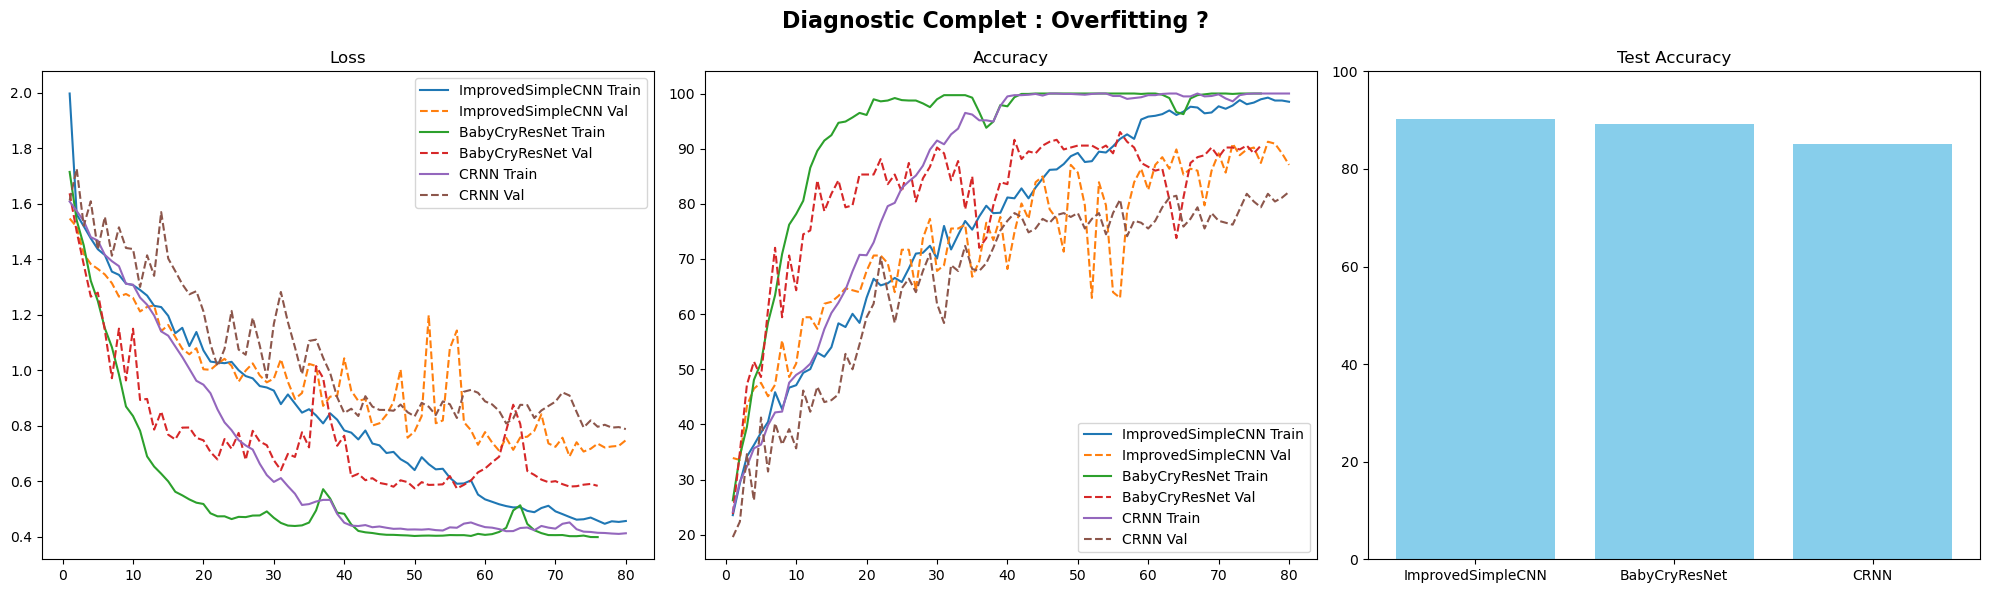

In [15]:
# Courbes détaillées pour voir l'overfitting
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, hist) in enumerate(histories.items()):
    epochs = range(1, len(hist['train_loss']) + 1)
    
    # Loss
    axs[0].plot(epochs, hist['train_loss'], label=f'{name} Train')
    axs[0].plot(epochs, hist['val_loss'], label=f'{name} Val', linestyle='--')
    axs[0].set_title('Loss')
    axs[0].legend()
    
    # Accuracy
    axs[1].plot(epochs, [x*100 for x in hist['train_acc']], label=f'{name} Train')
    axs[1].plot(epochs, [x*100 for x in hist['val_acc']], label=f'{name} Val', linestyle='--')
    axs[1].set_title('Accuracy')
    axs[1].legend()
    
    # Bar Test Accuracy
    axs[2].bar(name, results[name]['accuracy'], color='skyblue')
    axs[2].set_title('Test Accuracy')
    axs[2].set_ylim(0, 100)

plt.suptitle('Diagnostic Complet : Overfitting ?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
print(" DIAGNOSTIC OVERFITTING\n")
for name in histories.keys():
    hist = histories[name]
    train_acc = hist['train_acc'][-1] * 100
    val_acc = max(hist['val_acc']) * 100
    test_acc = results[name]['accuracy']
    gap = train_acc - val_acc
    
    print(f"{name:20} → Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Test: {test_acc:.2f}% | Gap: {gap:.2f}%")
    
    if gap > 15:
        print("   → **Overfitting fort**")
    elif gap > 8:
        print("   → Overfitting modéré")
    else:
        print("   → **Bon équilibre**")
    print("-" * 70)

 DIAGNOSTIC OVERFITTING

ImprovedSimpleCNN    → Train: 98.50% | Val: 91.26% | Test: 90.24% | Gap: 7.25%
   → **Bon équilibre**
----------------------------------------------------------------------
BabyCryResNet        → Train: 100.00% | Val: 93.01% | Test: 89.20% | Gap: 6.99%
   → **Bon équilibre**
----------------------------------------------------------------------
CRNN                 → Train: 100.00% | Val: 82.17% | Test: 85.02% | Gap: 17.83%
   → **Overfitting fort**
----------------------------------------------------------------------


# Conclusion

In [17]:
best_model = max(results, key=lambda x: results[x]['accuracy'])
print("_"*70)
print("CONCLUSION DU PROJET")
print("_"*70)
print(f"Meilleur modèle          : {best_model}")
print(f"Accuracy sur Test Set    : {results[best_model]['accuracy']:.2f}%")
print(f"F1-Macro                 : {results[best_model]['f1_macro']:.2f}%")
print(f"\nChoix final : {best_model} (meilleure généralisation)")

print("\nPoints forts :")
print("• Bonne augmentation de données")
print("• Comparaison de 3 architectures différentes")
print("• Techniques modernes (Label Smoothing, Early Stopping, BatchNorm)")
print("• Interprétabilité (Grad-CAM + ROC)")

print("\nLimites & Perspectives :")
print("• Dataset encore relativement petit")
print("• Possibilité d'améliorer avec plus de SpecAugment")
print("• Prochaines étapes : Déploiement Gradio + Rapport")

______________________________________________________________________
CONCLUSION DU PROJET
______________________________________________________________________
Meilleur modèle          : ImprovedSimpleCNN
Accuracy sur Test Set    : 90.24%
F1-Macro                 : 90.18%

Choix final : ImprovedSimpleCNN (meilleure généralisation)

Points forts :
• Bonne augmentation de données
• Comparaison de 3 architectures différentes
• Techniques modernes (Label Smoothing, Early Stopping, BatchNorm)
• Interprétabilité (Grad-CAM + ROC)

Limites & Perspectives :
• Dataset encore relativement petit
• Possibilité d'améliorer avec plus de SpecAugment
• Prochaines étapes : Déploiement Gradio + Rapport
